# Corporate HR People-Analytics Cube

### Submitted By: Mobeen Maroof
### Registration No: Mtech-DS26013

## Objective
The objective of this project is to clean and deduplicate a messy employee HR database using Python and Pandas, ensuring accurate and consistent employee records. It also aims to perform HR analytics by engineering useful features such as employee tenure and attrition risk, and visualizing key insights through charts and dashboards for better decision-making.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [15]:
df = pd.read_csv("employee_data.csv")

In [16]:
df.head(10)

,EmployeeID,Name,Department,Salary,Email,JoiningDate,Status
0,101,Ali Khan,HR,50000,ali@gmail.com,7/10/2009,Active
1,102,Sara Ahmed,IT,70000,sara@gmail.com,9/11/2011,Active
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com,11/12/2015,On Leave
3,104,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated
4,105,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com,2/15/2016,Retired
6,107,Ayesha Malik,IT,75000,ayesha@gmail.com,9/16/2017,Inactive
7,108,Hamza Sheikh,Finance,68000,hamza@gmail.com,5/17/2007,Resigned
8,109,Usman Raza,Sales,45000,usman@gmail.com,12/18/2014,Probation
9,110,Zara Noor,HR,55000,zara@gmail.com,8/19/2019,Active


In [17]:
print("Rows and Columns:", df.shape)

Rows and Columns: (42, 7)


In [18]:
df.columns

Index(['EmployeeID', 'Name', 'Department', 'Salary', 'Email', 'JoiningDate',
       'Status'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   EmployeeID   42 non-null     int64 
 1   Name         42 non-null     object
 2   Department   42 non-null     object
 3   Salary       42 non-null     int64 
 4   Email        42 non-null     object
 5   JoiningDate  42 non-null     object
 6   Status       42 non-null     object
dtypes: int64(2), object(5)
memory usage: 2.4+ KB


In [20]:
df.describe()

,EmployeeID,Salary
count,42.000000,42.000000
mean,121.500000,57023.809524
std,12.267844,10780.488462
min,101.000000,44000.000000
25%,111.250000,48250.000000
50%,121.500000,53500.000000
75%,131.750000,66875.000000
max,142.000000,81000.000000


In [21]:
df.isnull().sum()

EmployeeID     0
Name           0
Department     0
Salary         0
Email          0
JoiningDate    0
Status         0
dtype: int64

In [22]:
duplicates = df[df.duplicated()]
duplicates

,EmployeeID,Name,Department,Salary,Email,JoiningDate,Status


In [23]:
print("Complete Duplicate Rows :", df.duplicated().sum())
print("Duplicate Employee IDs  :", df.duplicated(subset=['EmployeeID']).sum())
print("Duplicate Emails        :", df.duplicated(subset=['Email']).sum())
print("Duplicate Names         :", df.duplicated(subset=['Name']).sum())
print("Duplicate Name+Dept     :", df.duplicated(subset=['Name','Department']).sum())
print("Duplicate Name+Dept+Salary :", df.duplicated(subset=['Name','Department','Salary']).sum())

Complete Duplicate Rows : 0
Duplicate Employee IDs  : 0
Duplicate Emails        : 13
Duplicate Names         : 10
Duplicate Name+Dept     : 10
Duplicate Name+Dept+Salary : 10


In [24]:
duplicates = df[df.duplicated(subset=["Name", "Email"], keep=False)]
duplicates

,EmployeeID,Name,Department,Salary,Email,JoiningDate,Status
0,101,Ali Khan,HR,50000,ali@gmail.com,7/10/2009,Active
1,102,Sara Ahmed,IT,70000,sara@gmail.com,9/11/2011,Active
3,104,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated
4,105,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com,2/15/2016,Retired
8,109,Usman Raza,Sales,45000,usman@gmail.com,12/18/2014,Probation
10,111,Ali Khan,HR,50000,ali@gmail.com,4/20/2008,Terminated
13,114,Noor Ali,Marketing,47000,noor@gmail.com,2/23/2020,On Leave
19,120,Iqra Ahmed,HR,56000,iqra@gmail.com,12/29/2011,Inactive
23,124,Rida Noor,Marketing,49000,rida@gmail.com,6/2/2020,Retired


In [25]:
df["Name"] = df["Name"].str.strip()

In [26]:
df["Name"] = df["Name"].str.title()

In [27]:
df.head()

,EmployeeID,Name,Department,Salary,Email,JoiningDate,Status
0,101,Ali Khan,HR,50000,ali@gmail.com,7/10/2009,Active
1,102,Sara Ahmed,IT,70000,sara@gmail.com,9/11/2011,Active
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com,11/12/2015,On Leave
3,104,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated
4,105,Fatima Noor,HR,52000,fatima@gmail.com,5/13/2019,Terminated


In [28]:
df = df.drop_duplicates(
    subset=['Name', 'Department', 'Salary'],
    keep='first'
)

In [29]:
df = df.drop_duplicates(subset=['Email'], keep='last')

In [30]:
print("Complete Duplicate Rows :", df.duplicated().sum())
print("Duplicate Employee IDs  :", df.duplicated(subset=['EmployeeID']).sum())
print("Duplicate Emails        :", df.duplicated(subset=['Email']).sum())
print("Duplicate Names         :", df.duplicated(subset=['Name']).sum())
print("Duplicate Name+Dept     :", df.duplicated(subset=['Name','Department']).sum())
print("Duplicate Name+Dept+Salary :", df.duplicated(subset=['Name','Department','Salary']).sum())

Complete Duplicate Rows : 0
Duplicate Employee IDs  : 0
Duplicate Emails        : 0
Duplicate Names         : 0
Duplicate Name+Dept     : 0
Duplicate Name+Dept+Salary : 0


In [31]:
print(df.shape)

(29, 7)


In [32]:
print(df.duplicated().sum())

0


In [33]:
department = df["Department"].value_counts()

department

Department
HR           9
IT           6
Finance      6
Sales        5
Marketing    3
Name: count, dtype: int64

In [35]:
df['JoiningDate'] = pd.to_datetime(df['JoiningDate'])

In [36]:
from datetime import datetime

today = datetime.today()

df["Experience"] = (
    (today - df["JoiningDate"]).dt.days/365
).round(1)

In [37]:
def salary_band(x):

    if x<50000:
        return "Low"

    elif x<70000:
        return "Medium"

    else:
        return "High"

df["SalaryBand"]=df["Salary"].apply(salary_band)

In [38]:
df["IsActive"]=df["Status"].apply(
    lambda x:1 if x=="Active" else 0
)

In [39]:
attrition = ["Resigned","Terminated","Retired"]

df["Attrition"] = df["Status"].apply(
    lambda x:"Yes" if x in attrition else "No"
)

In [40]:
def tenure(x):

    if x<2:
        return "New"

    elif x<5:
        return "Mid"

    else:
        return "Senior"

df["Tenure"]=df["Experience"].apply(tenure)

In [41]:
print(df.shape[0])

29


In [43]:
print(df["Salary"].mean())

58362.06896551724


In [44]:
rate=(df["Attrition"]=="Yes").mean()*100

print(rate)

20.689655172413794


In [45]:
print(df["Status"].value_counts())

Status
Active        12
Inactive       6
Probation      3
On Leave       2
Terminated     2
Retired        2
Resigned       2
Name: count, dtype: int64


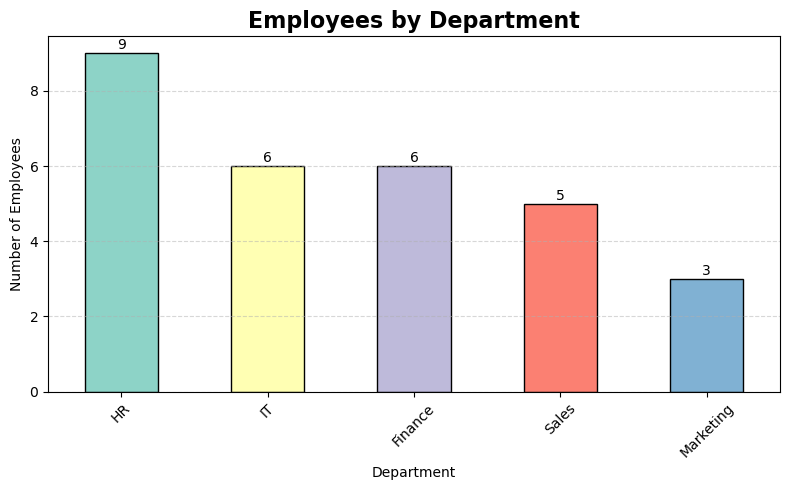

In [47]:
department = df["Department"].value_counts()

colors = plt.cm.Set3(range(len(department)))

department.plot(
    kind="bar",
    figsize=(8, 5),
    color=colors,
    edgecolor="black"
)

plt.title("Employees by Department", fontsize=16, fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

for i, value in enumerate(department.values):
    plt.text(i, value + 0.1, str(value), ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

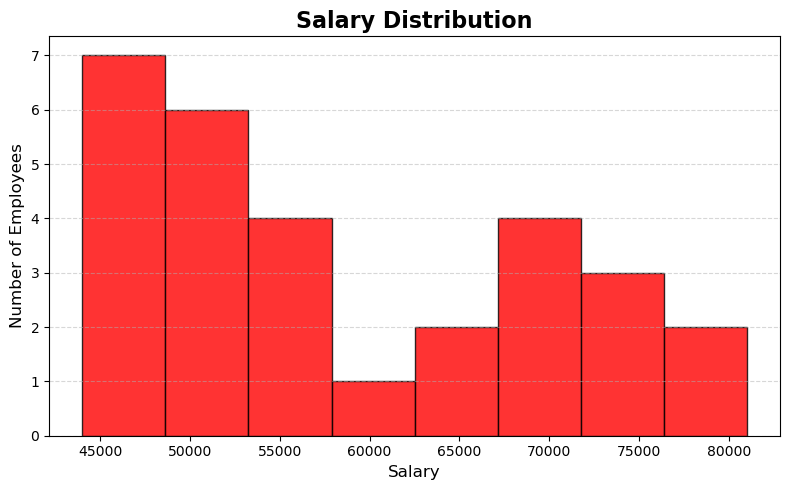

In [55]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Salary"],
    bins=8,
    color="red",
    edgecolor="black",
    alpha=0.8
)
plt.title("Salary Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Salary", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

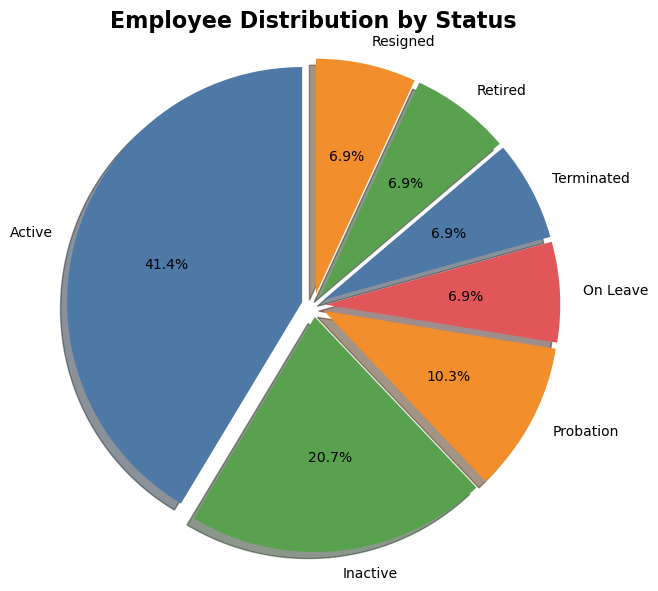

In [51]:
status = df["Status"].value_counts()

colors = ["#4E79A7", "#59A14F", "#F28E2B", "#E15759"]

plt.figure(figsize=(7,7))

plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors[:len(status)],
    shadow=True,
    explode=[0.05] * len(status)
)

plt.title("Employee Distribution by Status", fontsize=16, fontweight="bold")
plt.axis("equal")   

plt.show()

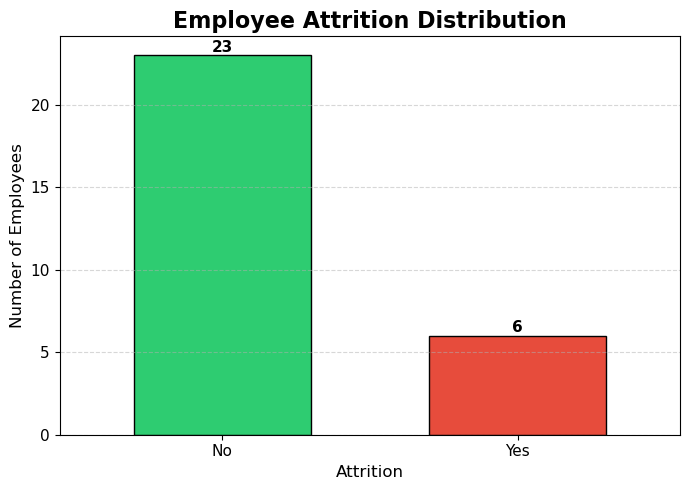

In [52]:
attrition = df["Attrition"].value_counts()

# Custom colors
colors = ["#2ECC71", "#E74C3C"]   

plt.figure(figsize=(7,5))

attrition.plot(
    kind="bar",
    color=colors[:len(attrition)],
    edgecolor="black",
    width=0.6
)
plt.title("Employee Attrition Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(attrition):
    plt.text(i, value + 0.2, str(value), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

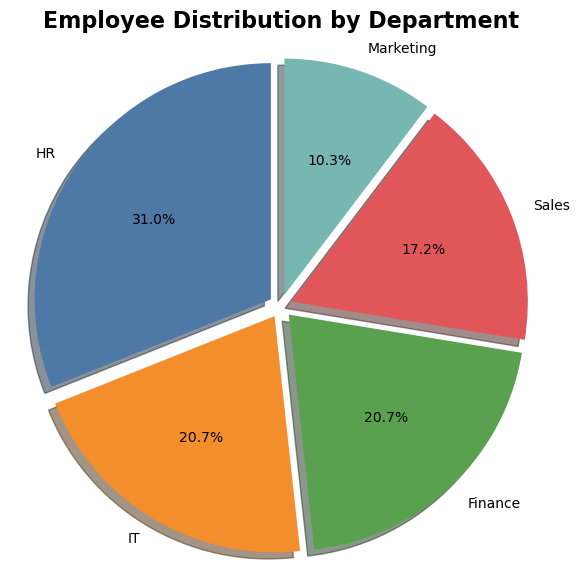

In [50]:
department = df["Department"].value_counts()
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2"]
plt.figure(figsize=(7,7))

plt.pie(
    department,
    labels=department.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    shadow=True,
    explode=[0.05]*len(department)
)
plt.title("Employee Distribution by Department", fontsize=16, fontweight="bold")
plt.axis("equal")
plt.show()

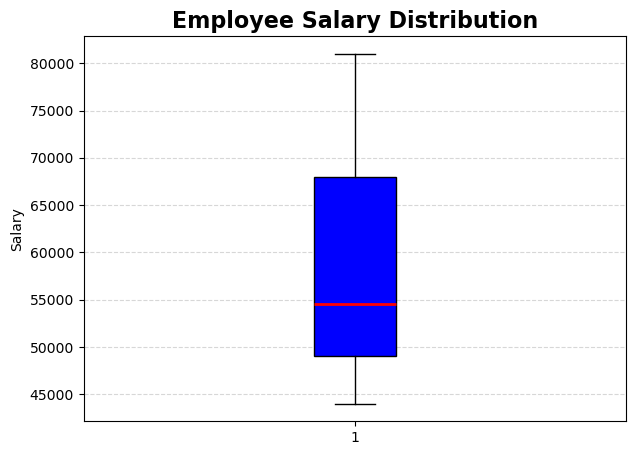

In [56]:
plt.figure(figsize=(7,5))

plt.boxplot(
    df["Salary"],
    patch_artist=True,
    boxprops=dict(facecolor="blue"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Employee Salary Distribution", fontsize=16, fontweight="bold")
plt.ylabel("Salary")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

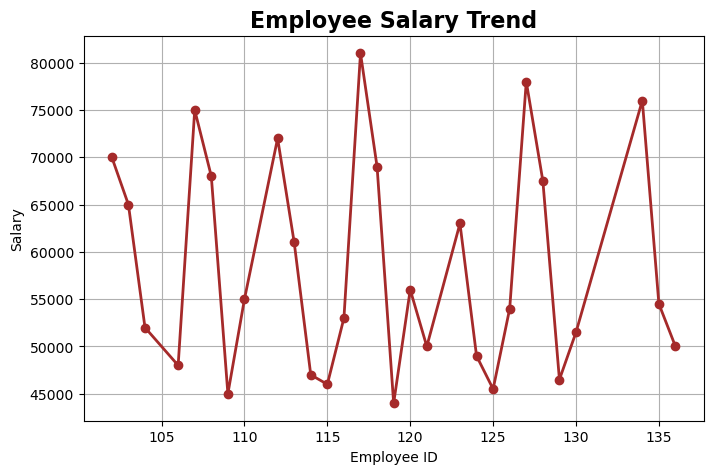

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    df["EmployeeID"],
    df["Salary"],
    marker="o",
    color="brown",
    linewidth=2
)

plt.title("Employee Salary Trend", fontsize=16, fontweight="bold")
plt.xlabel("Employee ID")
plt.ylabel("Salary")

plt.grid(True)

plt.show()

In [58]:
print("Average Salary =", df["Salary"].mean())

Average Salary = 58362.06896551724


In [59]:
print("Highest Salary =", df["Salary"].max())

Highest Salary = 81000


In [60]:
print("Lowest Salary =", df["Salary"].min())

Lowest Salary = 44000


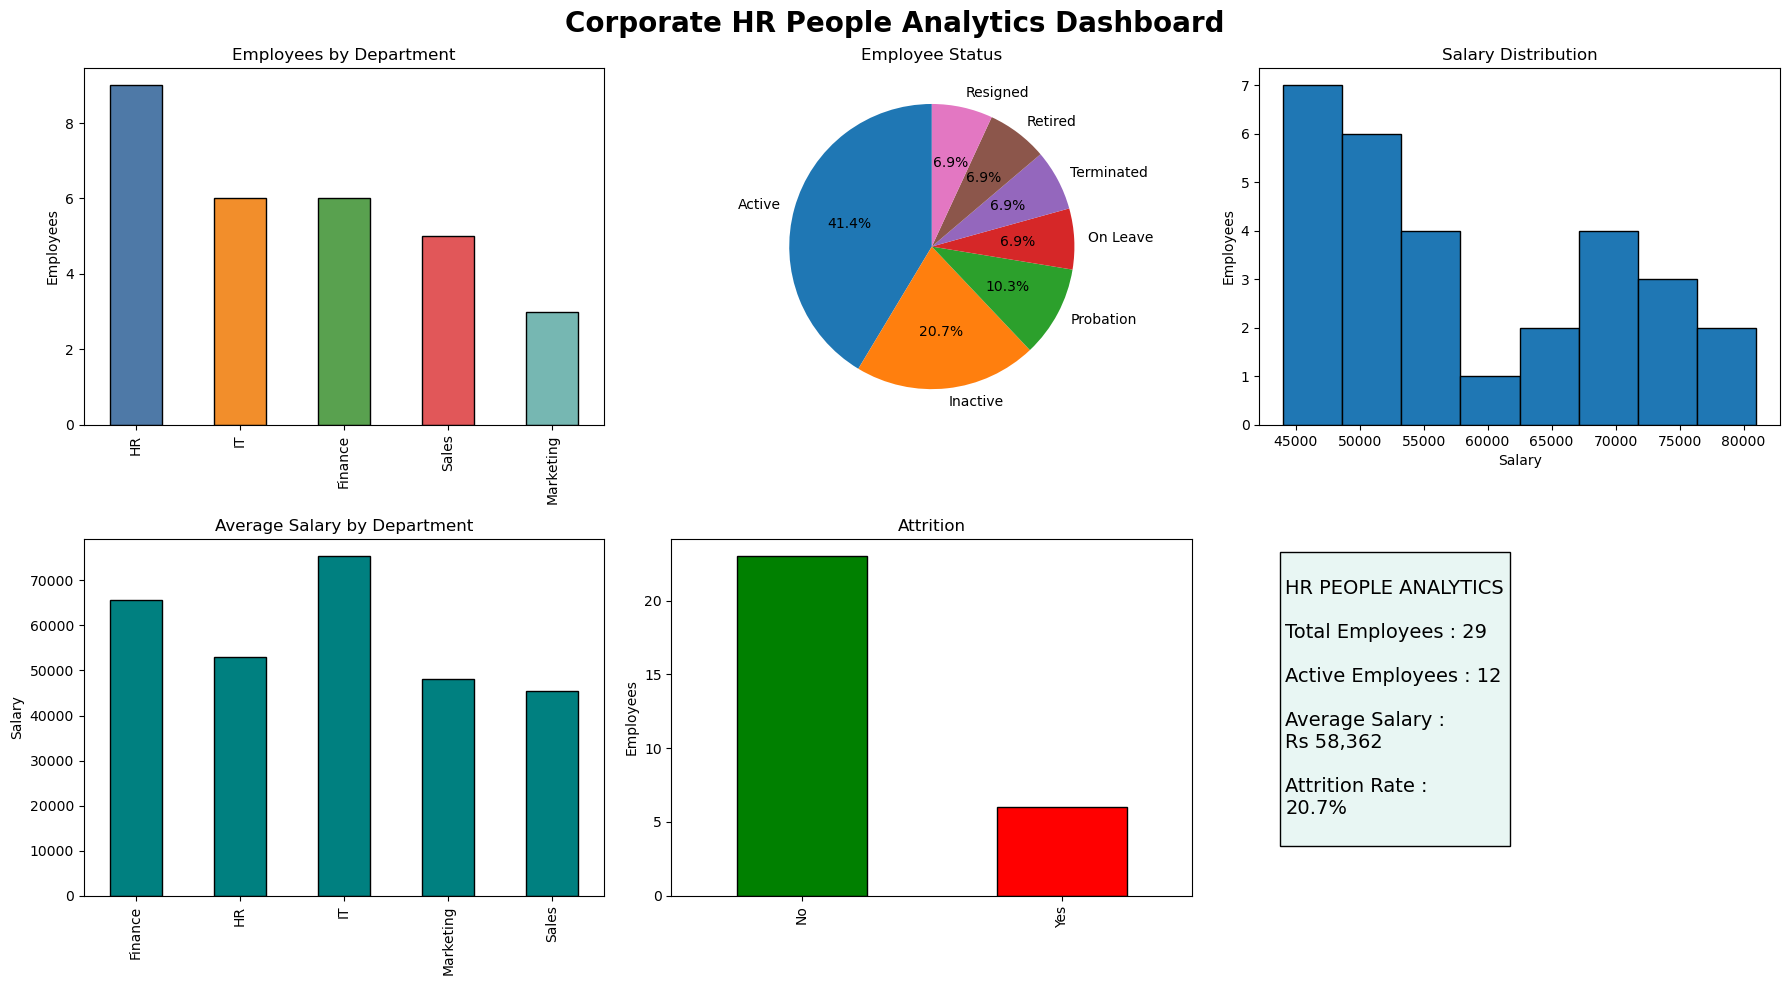

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(18,10))

# --------------------------
# 1. Department Distribution
# --------------------------
department = df["Department"].value_counts()

department.plot(
    kind="bar",
    ax=ax[0,0],
    color=["#4E79A7","#F28E2B","#59A14F","#E15759","#76B7B2"],
    edgecolor="black"
)

ax[0,0].set_title("Employees by Department")
ax[0,0].set_xlabel("")
ax[0,0].set_ylabel("Employees")

# --------------------------
# 2. Employee Status
# --------------------------
status = df["Status"].value_counts()

status.plot(
    kind="pie",
    ax=ax[0,1],
    autopct="%1.1f%%",
    startangle=90
)

ax[0,1].set_ylabel("")
ax[0,1].set_title("Employee Status")

# --------------------------
# 3. Salary Distribution
# --------------------------
ax[0,2].hist(
    df["Salary"],
    bins=8,
    edgecolor="black"
)

ax[0,2].set_title("Salary Distribution")
ax[0,2].set_xlabel("Salary")
ax[0,2].set_ylabel("Employees")

# --------------------------
# 4. Average Salary by Department
# --------------------------
avg_salary = df.groupby("Department")["Salary"].mean()

avg_salary.plot(
    kind="bar",
    ax=ax[1,0],
    color="teal",
    edgecolor="black"
)

ax[1,0].set_title("Average Salary by Department")
ax[1,0].set_xlabel("")
ax[1,0].set_ylabel("Salary")

# --------------------------
# 5. Attrition
# --------------------------
attrition = df["Attrition"].value_counts()

attrition.plot(
    kind="bar",
    ax=ax[1,1],
    color=["green","red"],
    edgecolor="black"
)

ax[1,1].set_title("Attrition")
ax[1,1].set_xlabel("")
ax[1,1].set_ylabel("Employees")

# --------------------------
# 6. KPI Panel
# --------------------------
ax[1,2].axis("off")

total = len(df)
active = (df["Status"]=="Active").sum()
avg_salary = df["Salary"].mean()
attrition_rate = (df["Attrition"]=="Yes").mean()*100

text = f"""
HR PEOPLE ANALYTICS

Total Employees : {total}

Active Employees : {active}

Average Salary :
Rs {avg_salary:,.0f}

Attrition Rate :
{attrition_rate:.1f}%
"""

ax[1,2].text(
    0.05,
    0.95,
    text,
    fontsize=14,
    va="top",
    bbox=dict(facecolor="#E8F6F3", edgecolor="black")
)

plt.suptitle(
    "Corporate HR People Analytics Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("HR_Dashboard.png", dpi=300)

plt.show()

In [61]:
df.to_csv("clean_employee_data.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
